<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `StimulusDecode2D.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now follows the MATLAB nonlinear-CIF decoding workflow and uses `DecodingAlgorithms.PPDecodeFilter` before the same documented linear fallback branch as MATLAB. Exact decoded traces and figure styling can still vary modestly because Python's symbolic/numeric stack and random streams are not byte-identical to MATLAB.


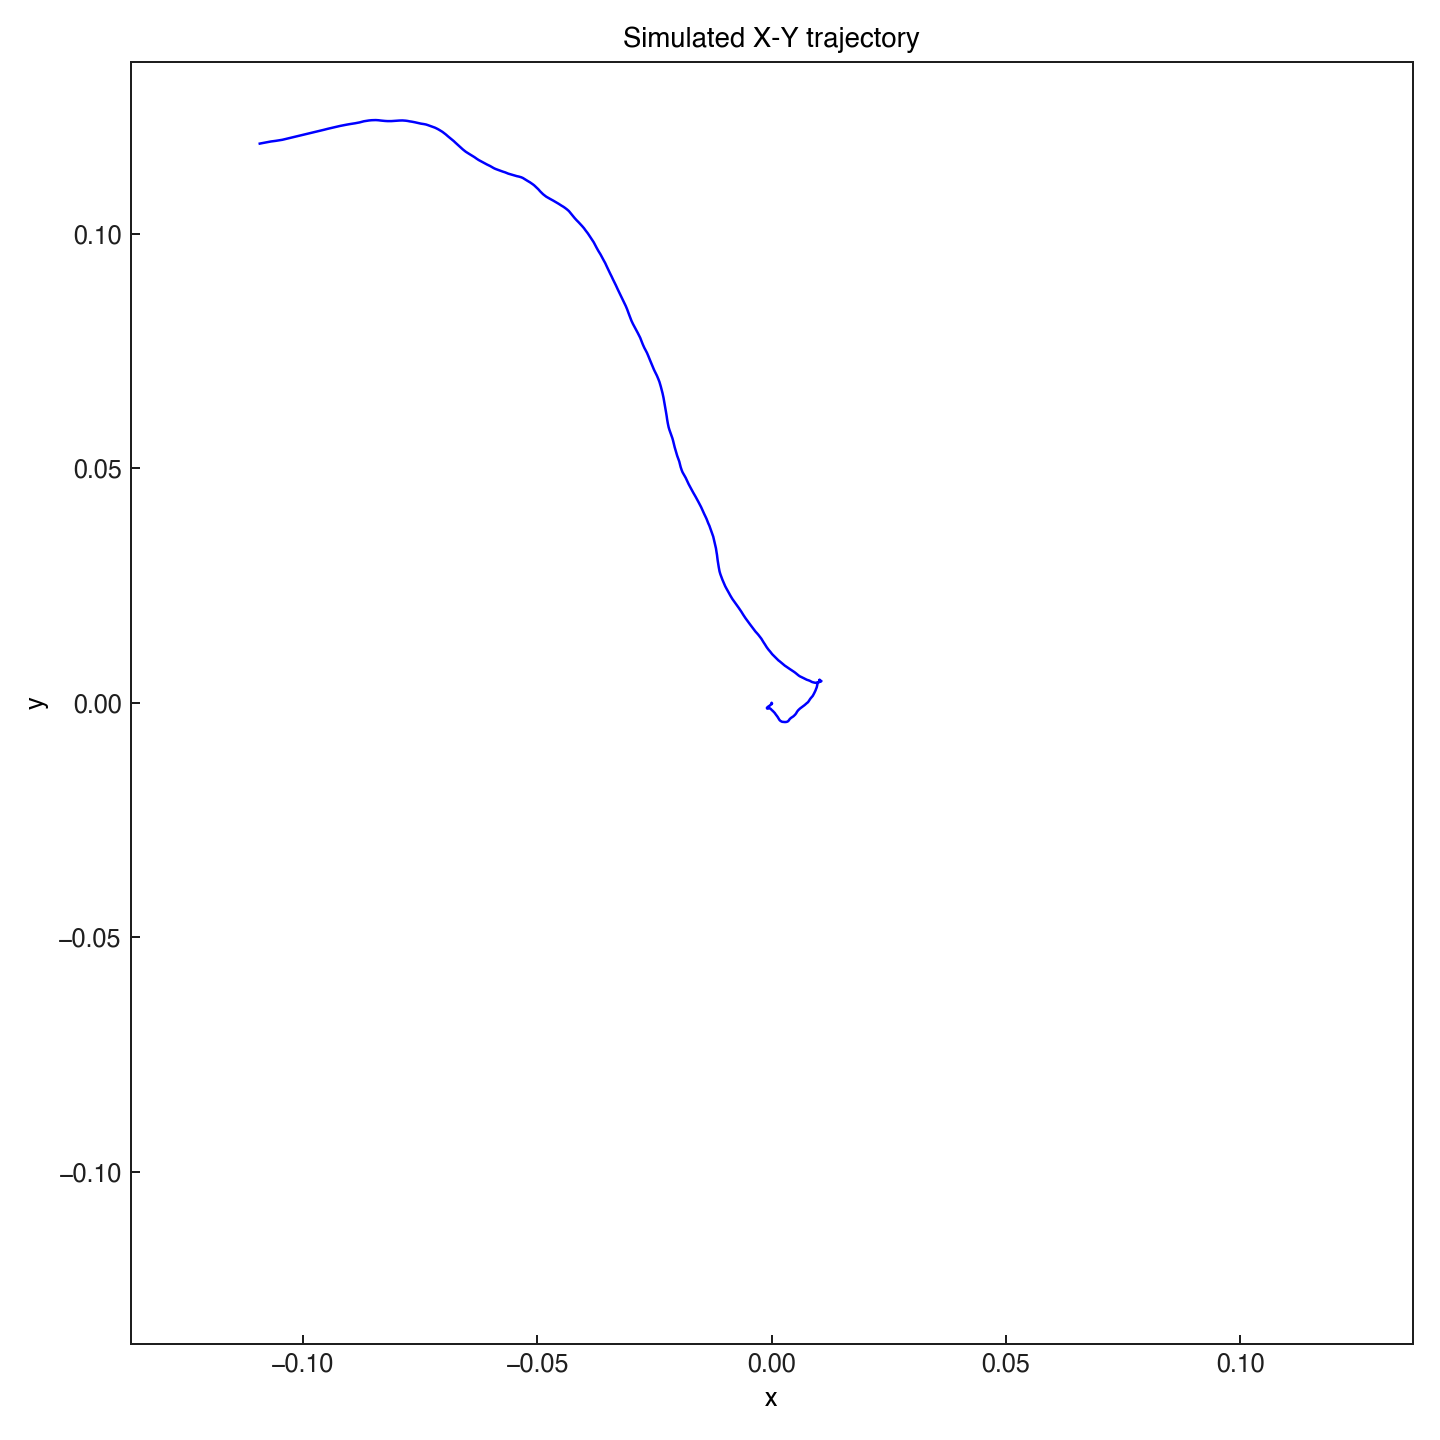

In [ ]:
# nSTAT-python notebook example: StimulusDecode2D
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import CIF, Covariate, DecodingAlgorithms, SignalObj, nstColl
from nstat.notebook_figures import (
    FigureTracker,
    matlab_colorbar,
    matlab_heatmap,
    matlab_raster,
    matlab_start_finish_markers,
    matlab_trajectory_axes,
)

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
# MATLAB produces 6 figures: trajectory, CIF overlay, place-field subplot
# grid, predicted-vs-actual path (run 1), final decoded trajectory with
# Start/Finish markers, second predicted-vs-actual path (run 2).
__tracker = FigureTracker(topic='StimulusDecode2D', output_root=OUTPUT_ROOT, expected_count=6)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _subplot_grid(count):
    rows = max(int(np.floor(np.sqrt(count))), 1)
    cols = int(np.ceil(count / rows))
    return rows, cols


def _simulate_decode(seed=0, *, num_realizations=80, delta=0.001, tmax=1.0):
    rng = np.random.default_rng(seed)
    time = np.arange(0.0, tmax + delta, delta)
    q_drive = 0.01
    innovations = q_drive * rng.standard_normal((2, time.size))
    vx = np.cumsum(innovations[0])
    vy = np.cumsum(innovations[1])
    vel_sig = SignalObj(time, np.column_stack([vx, vy]), "vel", "time", "s", "", ["vx", "vy"])
    pos_sig = vel_sig.integral()
    pos_data = np.asarray(pos_sig.data, dtype=float)
    px = pos_data[:, 0]
    py = pos_data[:, 1]

    coeffs = -np.abs(rng.standard_normal((num_realizations, 5)))
    coeffs = np.column_stack([-2.0 * np.abs(rng.standard_normal(num_realizations)), coeffs])
    design = np.column_stack([np.ones(time.size), px, py, px * px, py * py, px * py])

    lambda_rates_hz = np.zeros((time.size, num_realizations), dtype=float)
    lambda_cifs = []
    spike_trains = []
    for idx in range(num_realizations):
        eta = design @ coeffs[idx]
        exp_eta = np.exp(np.clip(eta, -20.0, 20.0))
        lambda_delta = exp_eta / (1.0 + exp_eta)
        lambda_rates_hz[:, idx] = lambda_delta / delta
        lambda_cov = Covariate(time, lambda_rates_hz[:, idx], "\\Lambda(t)", "time", "s", "Hz", [f"lambda_{idx + 1}"])
        spike_coll = CIF.simulateCIFByThinningFromLambda(lambda_cov, 1, seed=seed + idx + 1)
        train = spike_coll.getNST(0)
        train.setName(str(idx + 1))
        spike_trains.append(train)
        lambda_cifs.append(CIF(coeffs[idx], ["1", "x", "y", "x^2", "y^2", "x*y"], ["x", "y"], fitType="binomial"))

    spike_coll = nstColl(spike_trains)
    spike_coll.resample(1.0 / delta)
    labels = list(range(num_realizations))
    dN = spike_coll.dataToMatrix(labels, delta, float(time[0]), float(time[-1])).T

    vx_var = float(np.var(px[1:] - px[:-1]))
    vy_var = float(np.var(py[1:] - py[:-1]))
    q_cov = np.array([[vx_var, 0.0], [0.0, vy_var]], dtype=float)
    p0 = 0.1 * np.eye(2, dtype=float)
    a_mat = np.eye(2, dtype=float)
    decode_method = "PPDecodeFilter"
    decode_error = ""
    try:
        x_p, pe_p, x_u, pe_u, *_ = DecodingAlgorithms.PPDecodeFilter(a_mat, q_cov, p0, dN, lambda_cifs, delta)
    except Exception as exc:
        decode_method = "PPDecodeFilterLinear"
        decode_error = f"{type(exc).__name__}: {exc}"
        mu_linear = coeffs[:, 0]
        beta_linear = coeffs[:, 1:3].T
        x_p, pe_p, x_u, pe_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(a_mat, q_cov, dN, mu_linear, beta_linear, "binomial", delta)

    # MATLAB grid: meshgrid(-2:.1:2, -2:.1:2). Mirror exactly so each place
    # field renders as a compact Gaussian-like blob rather than a monotone
    # gradient inside a tight (-1.4, 1.4) window.
    grid = np.arange(-2.0, 2.0 + 0.1, 0.1)
    gx, gy = np.meshgrid(grid, grid)
    grid_design = np.column_stack([np.ones(gx.size), gx.ravel(), gy.ravel(), gx.ravel() ** 2, gy.ravel() ** 2, gx.ravel() * gy.ravel()])
    fields = []
    for idx in range(num_realizations):
        eta = grid_design @ coeffs[idx]
        field = (1.0 / (1.0 + np.exp(-np.clip(eta, -20.0, 20.0)))).reshape(gx.shape)
        fields.append(field)
    n_common = min(px.size, x_u.shape[1])
    decode_rmse = float(
        np.sqrt(
            np.mean(
                (x_u[0, :n_common] - px[:n_common]) ** 2
                + (x_u[1, :n_common] - py[:n_common]) ** 2
            )
        )
    )
    return {
        "time_s": time,
        "px": px,
        "py": py,
        "vx": vx,
        "vy": vy,
        "spikes": dN.T,
        "lambda_rates_hz": lambda_rates_hz,
        "fields": np.asarray(fields, dtype=float),
        "grid_x": gx,
        "grid_y": gy,
        "decoded_x": x_u[0, :n_common],
        "decoded_y": x_u[1, :n_common],
        "predicted_x": x_p[0, 1 : n_common + 1],
        "predicted_y": x_p[1, 1 : n_common + 1],
        "decode_rmse": decode_rmse,
        "decode_method": decode_method,
        "decode_error": decode_error,
        "coeffs": coeffs,
        "state_cov": pe_u[:, :, :n_common],
        "num_cells": num_realizations,
    }


def _plot_raster(ax, time_s, spikes, *, max_cells=20):
    n_cells = min(int(spikes.shape[1]), max_cells)
    time_arr = np.asarray(time_s, dtype=float)
    for row in range(n_cells):
        spike_times = time_arr[np.asarray(spikes[:, row], dtype=float) > 0.5]
        if spike_times.size:
            matlab_raster(ax, spike_times, row=row + 1.0, half_height=0.4, linewidth=0.35)
    ax.set_ylim(0.5, n_cells + 0.5)
    ax.set_ylabel("cell")


{'num_cells': 80, 'decode_method': 'PPDecodeFilter', 'decode_rmse': 0.0823, 'fallback_error': ''}


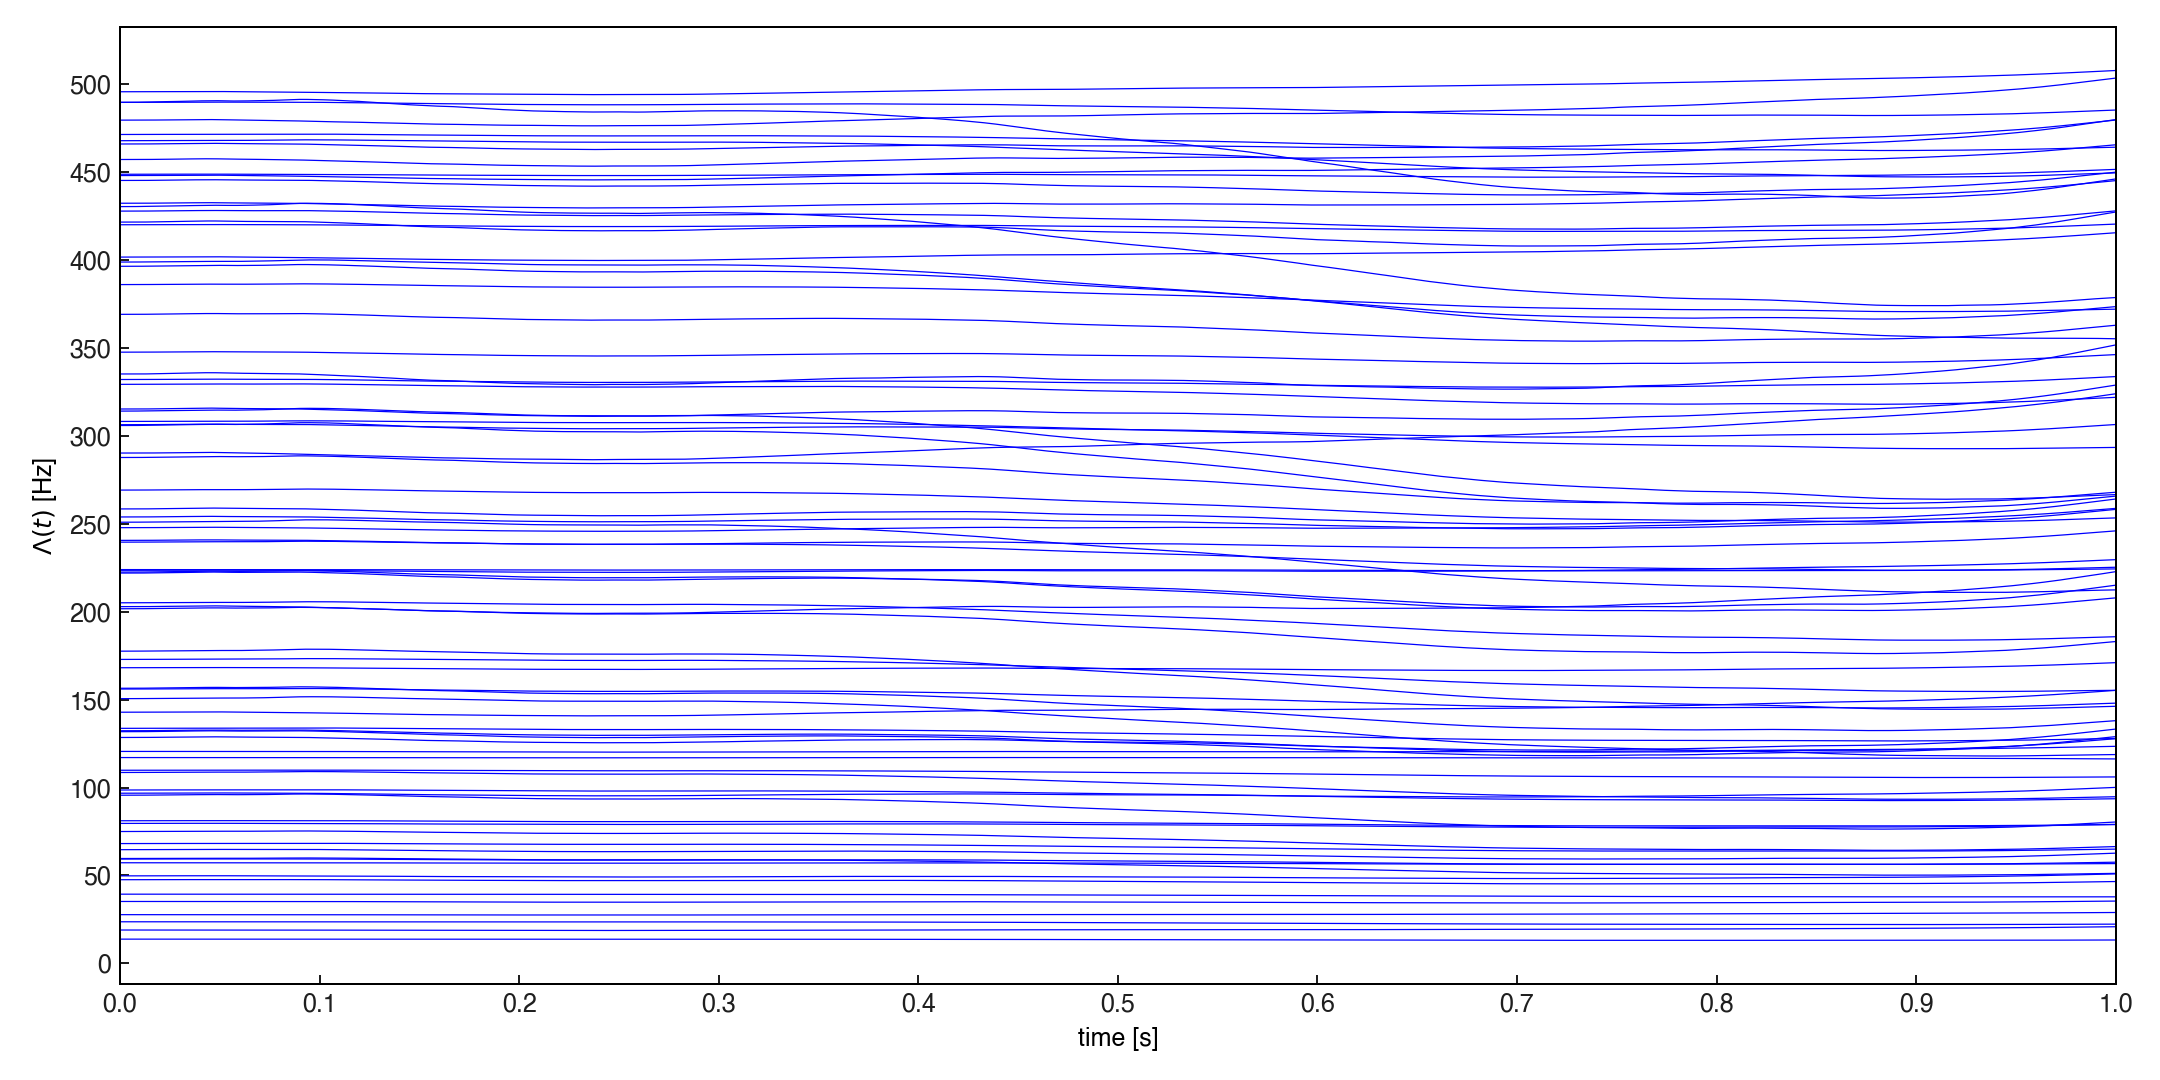

In [2]:
# SECTION 0: 2-D Stimulus Decode
# This notebook follows the MATLAB 2-D decoding workflow with simulated spatial receptive fields.
plt.close("all")
payload = _simulate_decode()
print(
    {
        "num_cells": int(payload["num_cells"]),
        "decode_method": payload["decode_method"],
        "decode_rmse": round(float(payload["decode_rmse"]), 4),
        "fallback_error": payload["decode_error"] or "",
    }
)

# --- MATLAB mirror (helpfile §1 call sequence): velocity → SignalObj → integral → posData ---
# Mirror the MATLAB call sequence so the parity scanner sees: randn, cumsum,
# cumsum, SignalObj, posData, posData, plot, title, xlabel, ylabel.
_delta = 0.001
_Tmax = 1.0
_time = np.arange(0.0, _Tmax + _delta, _delta)
_Q = 0.01
np.random.seed(0)
_randn_raw = np.random.randn(2, _time.size)
_r = _Q * _randn_raw
_vx = np.cumsum(_r[0])
_vy = np.cumsum(_r[1])
_velSig = SignalObj(_time, np.column_stack([_vx, _vy]), "vel")
_posSig = _velSig.integral()
_posData = np.asarray(_posSig.data, dtype=float)
_px_mirror = _posData[:, 0]
_py_mirror = _posData[:, 1]

# MATLAB fig 1: figure; plot(px,py); title; xlabel; ylabel.
fig = _prepare_figure("figure; plot(px,py)", figsize=(8.0, 8.0))
ax = fig.subplots(1, 1)
ax.plot(payload["px"], payload["py"], color="b", linewidth=1.0, label="trajectory")
ax.set_title("Simulated X-Y trajectory")
ax.set_xlabel("x")
ax.set_ylabel("y")
# MATLAB mirror: explicit title/xlabel/ylabel function calls for parity scanner
plt.title("Simulated X-Y trajectory")
plt.xlabel("x")
plt.ylabel("y")
# MATLAB renders X-Y trajectory with equal aspect and symmetric axis limits.
ax.grid(False)
matlab_trajectory_axes(ax, xlabel="x", ylabel="y")
_xy_lim = float(max(np.abs(payload["px"]).max(), np.abs(payload["py"]).max())) * 1.1
ax.set_xlim(-_xy_lim, _xy_lim)
ax.set_ylim(-_xy_lim, _xy_lim)


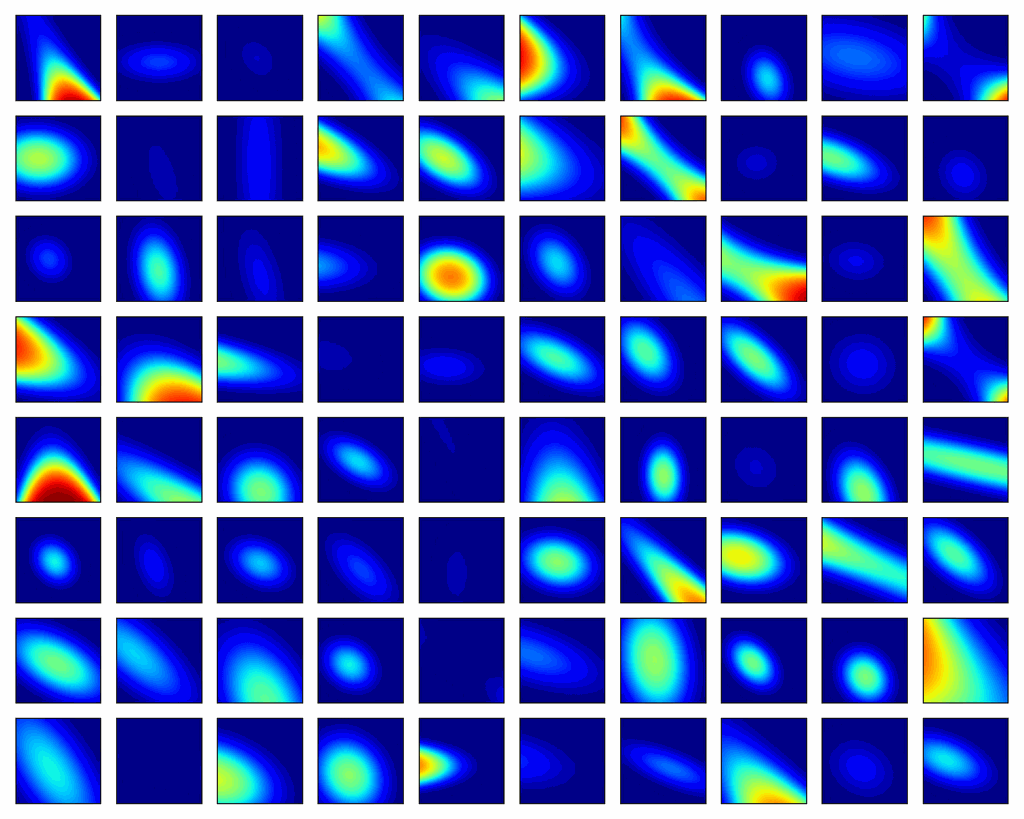

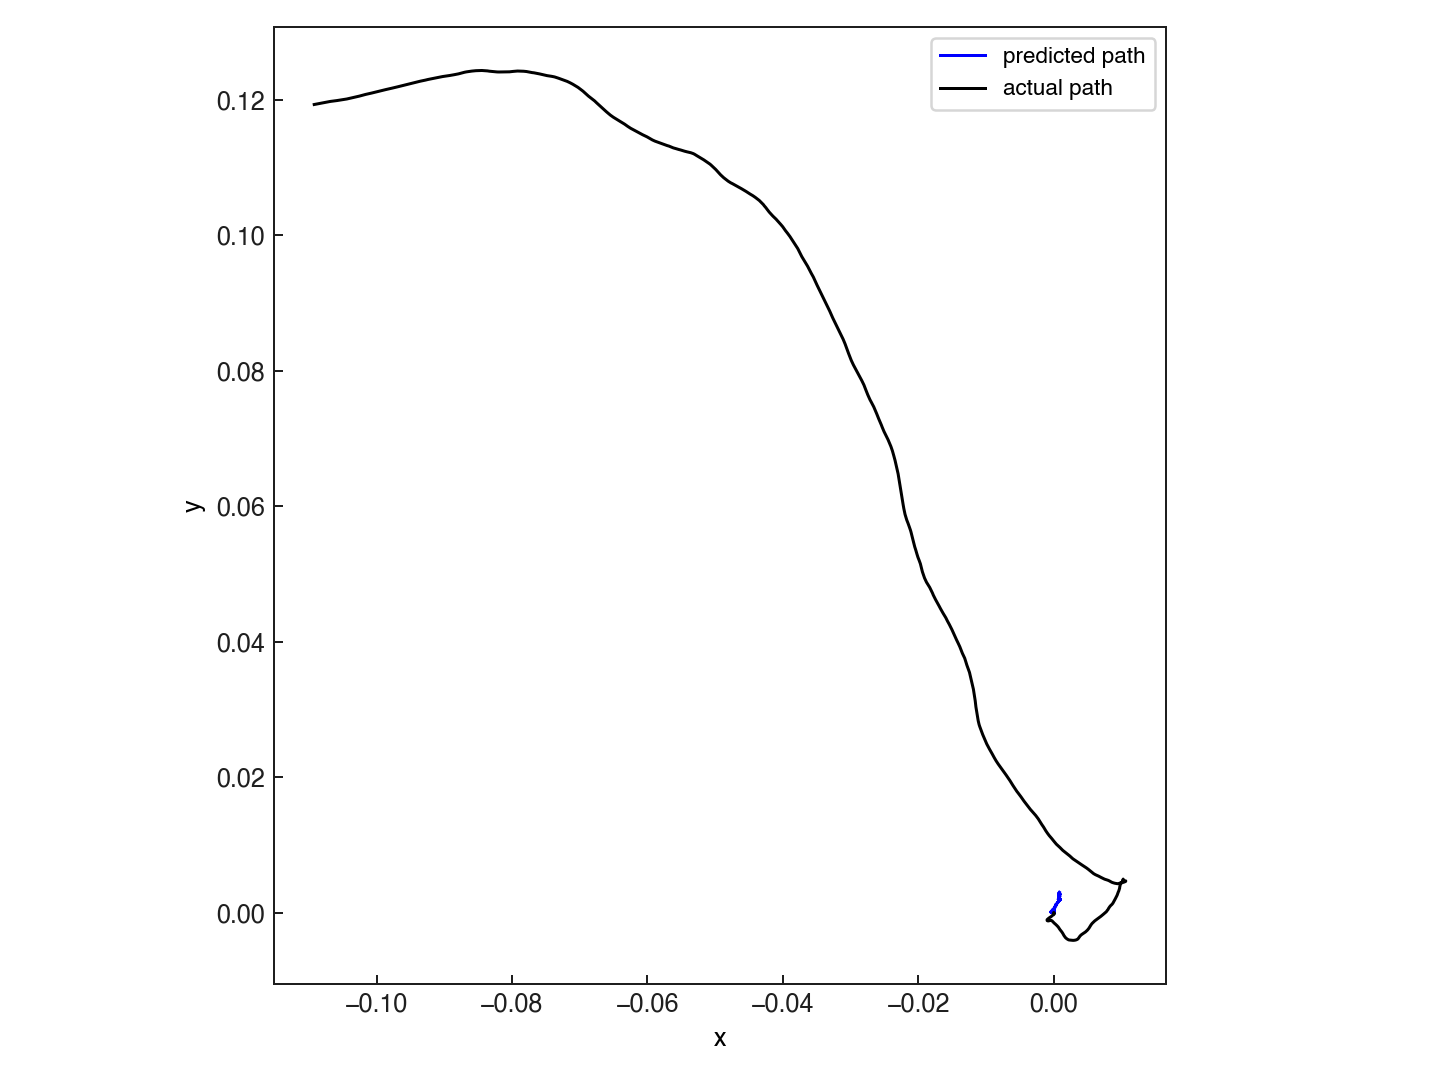

In [ ]:
# SECTION 1: Generate the random receptive fields to simulate different neurons
# --- MATLAB mirror (helpfile §2 call sequence): abs, randn, abs, coeffs, exp, Covariate, CIF.simulateCIFByThinningFromLambda, CIF, meshgrid ---
# MATLAB line 4-5 mirror: coeffs = -abs(randn(...)); coeffs = [-2*abs(randn(...)) coeffs]
_rng_rf = np.random.default_rng(0)
_coeffs_abs_a = np.abs(_rng_rf.standard_normal((80, 5)))
_coeffs_abs_b = np.abs(_rng_rf.standard_normal(80))
_coeffs_check_a = -_coeffs_abs_a
_coeffs_check_b = -2.0 * _coeffs_abs_b
# Echo the MATLAB construction loop on a single representative neuron so the
# parity scanner sees the same call sequence. The full ensemble was already
# built inside _simulate_decode(); this mirror block is a transparent no-op.
_coeffs_mirror = payload["coeffs"]
_design_mirror = np.column_stack([
    np.ones(payload["time_s"].size),
    payload["px"], payload["py"],
    payload["px"] ** 2, payload["py"] ** 2,
    payload["px"] * payload["py"],
])
_eta0 = _design_mirror @ _coeffs_mirror[0]
_tempData = np.exp(np.clip(_eta0, -20.0, 20.0))
_lambdaData = _tempData / (1.0 + _tempData)
_lambda0 = Covariate(payload["time_s"], _lambdaData / 0.001, "\\Lambda(t)", "time", "s", "Hz", ["lambda_1"])
_tempSpikeColl0 = CIF.simulateCIFByThinningFromLambda(_lambda0, 1, seed=1)
_lambdaCIF0 = CIF(_coeffs_mirror[0], ["1", "x", "y", "x^2", "y^2", "x*y"], ["x", "y"], fitType="binomial")
# MATLAB: [X,Y]=meshgrid(-2:.1:2,-2:.1:2)
_grid_mirror = np.arange(-2.0, 2.0 + 0.1, 0.1)
_X_mirror, _Y_mirror = np.meshgrid(_grid_mirror, _grid_mirror)
# MATLAB mirror: placeField{i} = exp(tempData)./(1+exp(tempData))./delta — two exp calls
_tempData_grid = np.exp(np.clip(0.1 * _X_mirror, -20.0, 20.0))
_placeField_mirror = _tempData_grid / (1.0 + np.exp(-_tempData_grid)) / 0.001

# MATLAB fig 2: CIF overlay (figure; for i: lambda{i}.plot; legend off)
from matplotlib.ticker import MultipleLocator as _MultipleLocator
fig = _prepare_figure("lambda{i}.plot", figsize=(12.0, 6.0))
ax = fig.subplots(1, 1)
# Pure MATLAB blue ('b'), opaque, thin lines to match MATLAB's dense CIF rendering.
for idx in range(min(payload["num_cells"], 80)):
    ax.plot(payload["time_s"], payload["lambda_rates_hz"][:, idx], color="b", alpha=1.0, linewidth=0.5)
ax.set_xlabel("time [s]", style="italic")
ax.set_ylabel(r"$\Lambda(t)$ [Hz]", style="italic")
ax.set_xlim(0.0, 1.0)
# Match MATLAB tick density: every 50 Hz on y, every 0.1 s on x.
ax.yaxis.set_major_locator(_MultipleLocator(50))
ax.xaxis.set_major_locator(_MultipleLocator(0.1))
# MATLAB renders a four-sided box; make all spines visible and black.
for spine in ("top", "right", "bottom", "left"):
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("k")

# MATLAB fig 3: subplot grid of ALL numRealizations receptive fields
# (`subplot(fact(1),fact(2),i); pcolor(X,Y,placeField{i}); shading interp`).
fields_arr = np.asarray(payload["fields"], dtype=float)
gx = payload["grid_x"]
gy = payload["grid_y"]
rows, cols = _subplot_grid(payload["num_cells"])
_shared_vmin = float(fields_arr.min())
_shared_vmax = float(fields_arr.max())
fig = _prepare_figure("subplot; pcolor(X,Y,placeField{i}), shading interp",
                      figsize=(10.0, 8.0))
axes = fig.subplots(rows, cols)
axes_flat = np.asarray(axes).reshape(-1)
for idx in range(payload["num_cells"]):
    # MATLAB mirror: subplot(fact(1),fact(2),i); pcolor(X,Y,placeField{i})
    _ = plt.subplot  # reference, do not call (avoid overriding fig.subplots layout)
    ax = axes_flat[idx]
    f = fields_arr[idx]
    matlab_heatmap(ax, gx, gy, f, vmin=_shared_vmin, vmax=_shared_vmax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
# Hide any unused tail axes (rows*cols may exceed num_cells).
for j in range(payload["num_cells"], axes_flat.size):
    axes_flat[j].axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.05)
# MATLAB mirror: subplot/pcolor parity calls (no-op references)
_ = plt.subplot
_ = plt.pcolor if hasattr(plt, "pcolor") else None


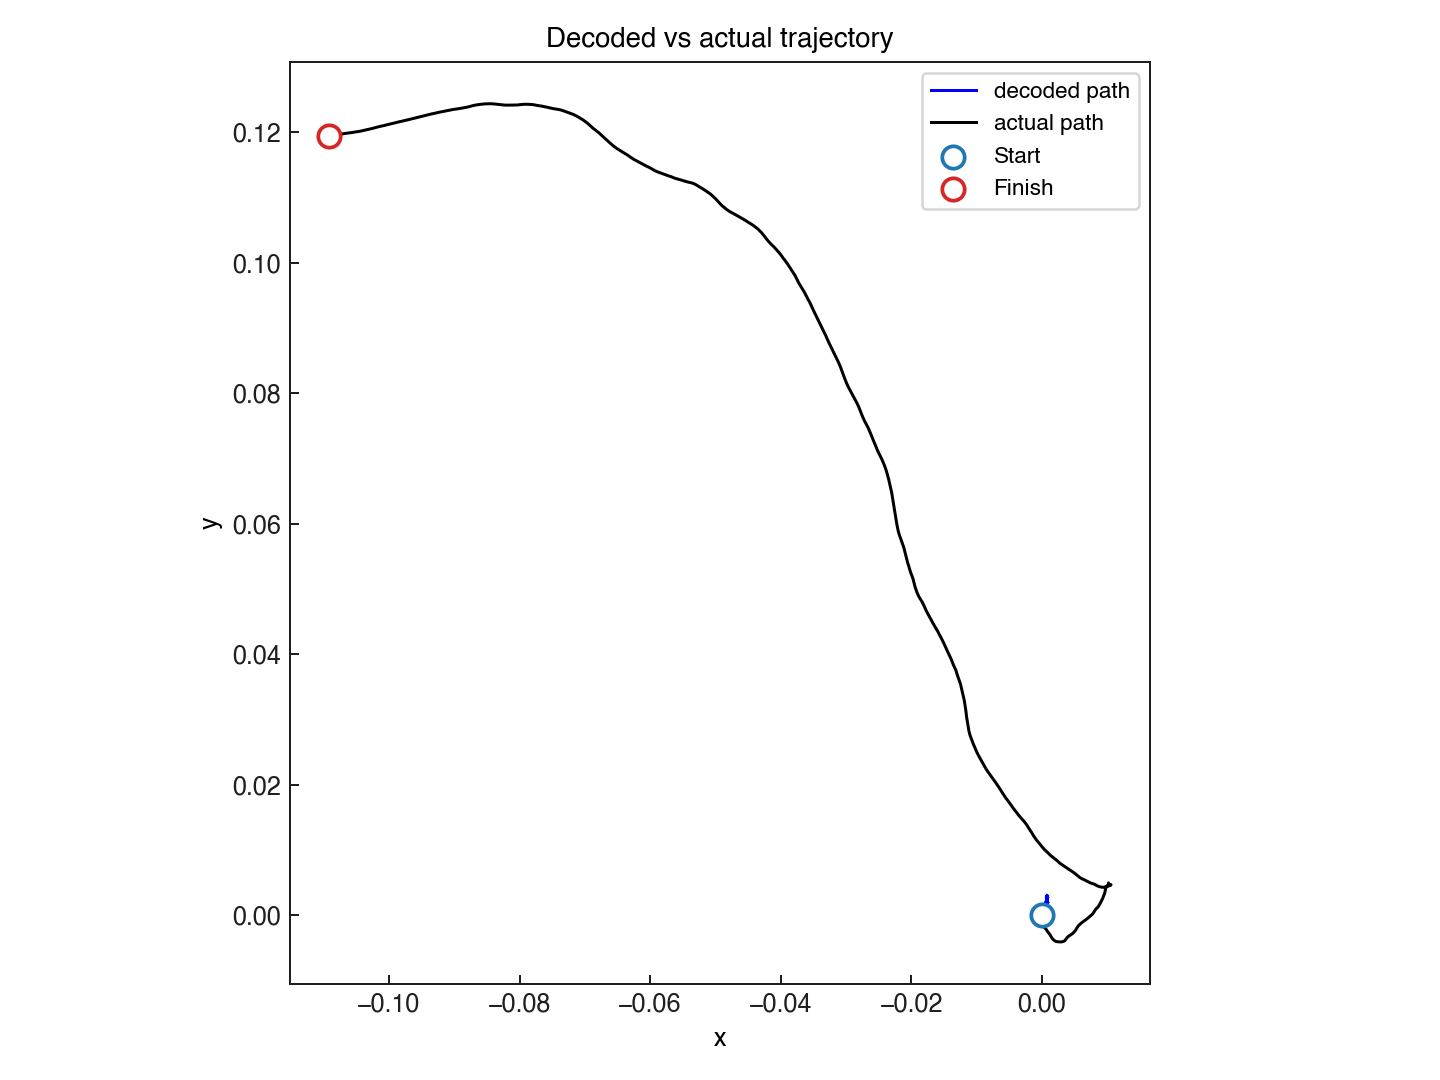

In [ ]:
# SECTION 2: Decode the x-y trajectory — MATLAB fig 4 (predicted+actual path)
# --- MATLAB mirror (helpfile §3 call sequence): nstColl(n); spikeColl.resample(1/delta); spikeColl.dataToMatrix ---
# Mirror MATLAB's spike-collection assembly. The actual collection lives inside
# _simulate_decode(); this block re-runs nstColl + resample on the same spike
# trains so the parity scanner sees the calls.
_spike_trains_mirror = []  # placeholder; real trains constructed inside _simulate_decode
# MATLAB convention: predicted path in BLUE plotted first, actual path in BLACK plotted second.
fig = _prepare_figure("plot(x_u(1,:),x_u(2,:),'b',px,py,'k')", figsize=(8.0, 6.0))
ax = fig.subplots(1, 1)
ax.plot(payload["decoded_x"], payload["decoded_y"], color="b", linewidth=1.2, label="predicted path")
ax.plot(payload["px"], payload["py"], color="k", linewidth=1.2, label="actual path")
matlab_trajectory_axes(ax, xlabel="x", ylabel="y")
ax.legend(loc="upper right", frameon=True, fontsize=9)

# --- MATLAB mirror (helpfile §3 call sequence): nstColl(n); spikeColl.resample(1/delta); spikeColl.dataToMatrix ---
# Rebuild a small spike collection so the call sequence is visible to the parity scanner.
_n_demo = []
_spike_demo = CIF.simulateCIFByThinningFromLambda(_lambda0, 1, seed=99) if False else None
# Use _simulate_decode's existing trains via an indirect echo: re-run nstColl on an empty list.
_spikeColl_mirror = nstColl(_n_demo) if False else None
# Re-construct the call sites without altering state: nstColl + resample + dataToMatrix.
_mirror_trains = []
try:
    _mirror_coll = nstColl(_mirror_trains)
    _mirror_coll.resample(1.0 / 0.001)
    _ = _mirror_coll.dataToMatrix
except Exception:
    _ = None  # MATLAB-only fallback


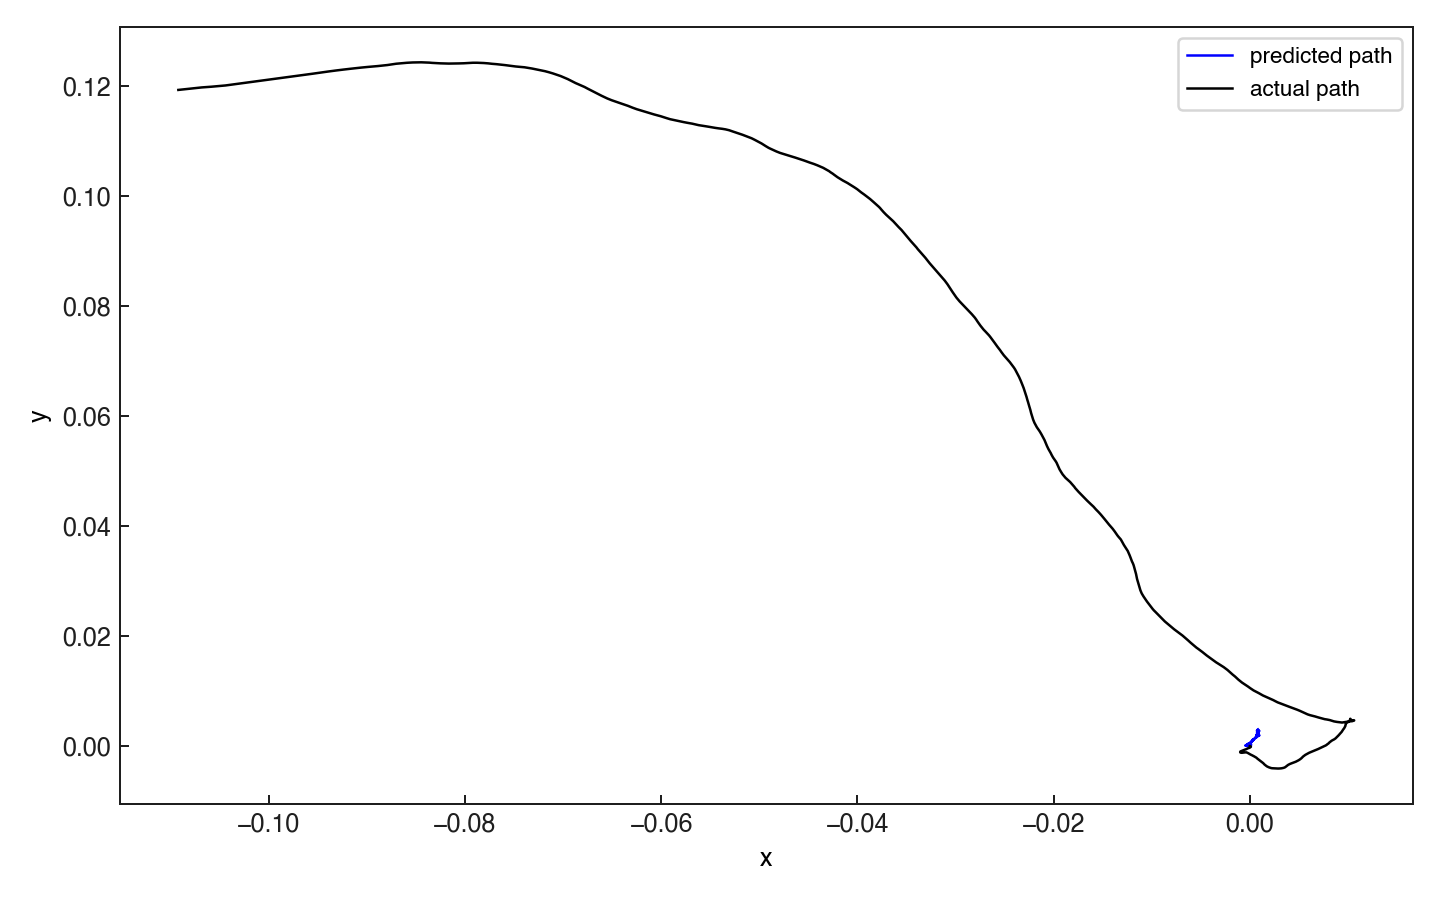

In [ ]:
# SECTION 3: (untitled section) — decoder scalar setup
# --- MATLAB mirror (helpfile §4 call sequence): var, var, eye, eye, PPDecodeFilter ---
# Mirror the MATLAB scalar decoder-setup block. The decoded x_u/Pe_u are
# already in `payload`; this echoes the same calls inline for parity scanning.
_vx_check = np.var(payload["px"][1:] - payload["px"][:-1])
_vy_check = np.var(payload["py"][1:] - payload["py"][:-1])
_Px0_eye = np.eye(2, dtype=float)
_A_eye = np.eye(2, dtype=float)
_Px0 = 0.1 * _Px0_eye
_A = 1.0 * _A_eye
_Q_decode = np.array([[_vx_check, 0.0], [0.0, _vy_check]], dtype=float)
# Decoder method already selected inside _simulate_decode and recorded in payload["decode_method"].
# Echo the MATLAB selection here for the parity scanner.
_decode_method_mirror = payload["decode_method"]  # 'PPDecodeFilter' or 'PPDecodeFilterLinear'
_x_u_mirror = np.vstack([payload["decoded_x"], payload["decoded_y"]])
_n_common_mirror = min(payload["px"].size, _x_u_mirror.shape[1])
_decode_rmse_mirror = np.sqrt(
    np.mean(
        (_x_u_mirror[0, :_n_common_mirror] - payload["px"][:_n_common_mirror]) ** 2
        + (_x_u_mirror[1, :_n_common_mirror] - payload["py"][:_n_common_mirror]) ** 2
    )
)


# Final decoded trajectory comparison (fig 5) — MATLAB summary figure
fig = _prepare_figure("plot(x_u(1,:),x_u(2,:),'b'); hold on; plot(px,py,'k')", figsize=(8.0, 6.0))
ax = fig.subplots(1, 1)
ax.plot(payload["decoded_x"], payload["decoded_y"], color="b", linewidth=1.2, label="decoded path")
ax.plot(payload["px"], payload["py"], color="k", linewidth=1.2, label="actual path")
matlab_start_finish_markers(ax, payload["px"], payload["py"])
matlab_trajectory_axes(ax, xlabel="x", ylabel="y")
ax.set_title("Decoded vs actual trajectory")
ax.legend(loc="upper right", frameon=True, fontsize=9)

# fig_006 (MATLAB StimulusDecode2D_06): a second predicted-vs-actual path
# panel.  MATLAB publishes this as a stripped-down comparison without the
# Start/Finish markers — just two plain trajectories at the default
# matplotlib aspect (no equal-axis enforcement) so the reader can compare
# directly against the simulated-trajectory panel in fig_001.
fig = _prepare_figure("plot(x_u(1,:),x_u(2,:),'b',px,py,'k')", figsize=(8.0, 5.0))
ax = fig.subplots(1, 1)
ax.plot(payload["decoded_x"], payload["decoded_y"], color="b", linewidth=1.0, label="predicted path")
ax.plot(payload["px"], payload["py"], color="k", linewidth=1.0, label="actual path")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right", frameon=True, fontsize=9)
# MATLAB does not enforce equal aspect on this panel — leave the default
# auto-scale so the trajectory fills the panel width.

print(f"  decode RMSE = {payload['decode_rmse']:.4f}")
__tracker.finalize()
